<a href="https://colab.research.google.com/github/PutriBalqisAfradinata/BigData26_A_2411531009_PutriBalqisAfradinata/blob/main/Praktikum3/Praktikum3_PutriBalqisAfradinata_2411531009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM 3 — PENGUMPULAN DAN PRA-PEMROSESAN DATA UNTUK BIG DATA

**Nama:** Putri Balqis Afradinata  
**NIM:** 2411531009  
**Platform:** Google Colab — Runtime CPU

Notebook ini mengikuti Modul Praktikum Big Data Praktikum 3. Bagian wajib K-1 s.d. K-10, K-11 sebagai stretch, Analisis Hasil, grafik wajib, Studi Kasus, Latihan 1–6, Tugas Praktikum 1–6, serta Pertanyaan Evaluasi 1–9.

## Konvensi dan catatan penting
Satu langkah K terdiri dari Markdown dan kode. Keputusan pra-pemrosesan dijelaskan sebelum kode. K-4 hanya jalur cadangan dan tidak dijalankan bila K-3 berhasil. K-11 bersifat tambahan/stretch.

**Catatan kompatibilitas K-2:** file Taxi Zone Lookup dibaca langsung dari response HTTP agar kompresi response ditangani `requests`, lalu disimpan sebagai CSV normal untuk dipakai K-10.

In [1]:
# K-1 — Lingkungan
import sys, time, os, json, sqlite3, gc, shutil, io
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod=__import__(nama); print(f"{nama:11s}: {getattr(mod,'__version__','tersedia')}")
    except ImportError: print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount('/content/drive')
DIR_MENTAH='/content/lapisan_mentah'
DIR_KURASI='/content/lapisan_terkurasi'
DIR_SIMPAN='/content/drive/MyDrive/BigData/Praktikum3'
for d in (DIR_MENTAH,DIR_KURASI,DIR_SIMPAN): os.makedirs(d,exist_ok=True)
proses=psutil.Process(os.getpid()); catatan=[]
def rss_mb(): return proses.memory_info().rss/1024**2
def ukur(label,fungsi):
    m0,t0=rss_mb(),time.perf_counter(); hasil=fungsi(); detik=time.perf_counter()-t0
    catatan.append({'langkah':label,'detik':round(detik,2),'delta_rss_mb':round(rss_mb()-m0,1)})
    print(f'[{label}] {detik:.2f} s'); return hasil
lineage=[]
def catat_sumber(nama,asal,jumlah_baris,keterangan=''):
    lineage.append({'sumber':nama,'asal':asal,'diambil_pada':pd.Timestamp.now('UTC').isoformat(),'jumlah_baris':jumlah_baris,'keterangan':keterangan})
    print(f'[lineage] {nama}: {jumlah_baris:,} baris')

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Mounted at /content/drive


## K-2 — Akuisisi 1: Unduhan Berkala yang Tahan Gagal

In [2]:
import requests, shutil, io

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Retry + exponential backoff + cache + penulisan atomik."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan)>0:
        print('cache ditemukan:',os.path.basename(tujuan)); return tujuan
    sementara=tujuan+'.part'
    for i in range(percobaan):
        try:
            with requests.get(url,stream=True,timeout=60) as r:
                r.raise_for_status()
                with open(sementara,'wb') as f: shutil.copyfileobj(r.raw,f)
            if os.path.getsize(sementara)==0: raise IOError('berkas kosong')
            os.replace(sementara,tujuan); return tujuan
        except Exception as e:
            jeda=jeda_awal*(2**i); print(f'percobaan {i+1} gagal ({e}); menunggu {jeda}s'); time.sleep(jeda)
    raise RuntimeError(f'gagal mengunduh setelah {percobaan} percobaan: {url}')

URL_TRIP='https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet'
URL_ZONA='https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
PATH_TRIP=os.path.join(DIR_MENTAH,'yellow_tripdata_2023-01.parquet')
PATH_ZONA=os.path.join(DIR_MENTAH,'taxi_zone_lookup.csv')
ukur('unduh trip',lambda:unduh_aman(URL_TRIP,PATH_TRIP))
ukur('unduh zona',lambda:unduh_aman(URL_ZONA,PATH_ZONA))
for pth in (PATH_TRIP,PATH_ZONA): print(os.path.basename(pth),'->',round(os.path.getsize(pth)/1024**2,2),'MB')
KOLOM=['tpep_pickup_datetime','tpep_dropoff_datetime','passenger_count','trip_distance','PULocationID','DOLocationID','payment_type','fare_amount','tip_amount','total_amount']
trip=ukur('baca trip',lambda:pd.read_parquet(PATH_TRIP,columns=KOLOM))
r_zona=requests.get(URL_ZONA,timeout=60); r_zona.raise_for_status()
zona=pd.read_csv(io.BytesIO(r_zona.content))
with open(PATH_ZONA,'wb') as f: f.write(r_zona.content)
zona=pd.read_csv(PATH_ZONA)
catat_sumber('trip',URL_TRIP,len(trip),'Parquet bulanan TLC')
catat_sumber('zona',URL_ZONA,len(zona),'tabel dimensi 265 zona')
print('Zona berhasil dibaca:',len(zona),'baris'); zona.head()

[unduh trip] 1.09 s
[unduh zona] 0.06 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.0 MB
[baca trip] 1.01 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris
Zona berhasil dibaca: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


## K-3 — Akuisisi 2: Memanggil API JSON

In [3]:
API_CUACA='https://archive-api.open-meteo.com/v1/archive'
def ambil_cuaca(mulai,selesai,lat=40.7128,lon=-74.0060,percobaan=3):
    parameter={'latitude':lat,'longitude':lon,'start_date':mulai,'end_date':selesai,'hourly':'temperature_2m,precipitation','timezone':'America/New_York'}
    for i in range(percobaan):
        r=requests.get(API_CUACA,params=parameter,timeout=60)
        if r.status_code==200:
            data=r.json()
            if 'hourly' not in data: raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data['hourly'])
        if r.status_code in (429,500,502,503): time.sleep(2**i); continue
        r.raise_for_status()
    raise RuntimeError('API cuaca tidak merespons dengan benar')
cuaca=ukur('ambil cuaca',lambda:ambil_cuaca('2023-01-01','2023-01-31'))
cuaca['time']=pd.to_datetime(cuaca['time'])
cuaca=cuaca.rename(columns={'time':'jam_mulai','temperature_2m':'suhu_c','precipitation':'hujan_mm'})
catat_sumber('cuaca',API_CUACA,len(cuaca),'Open-Meteo hourly archive'); cuaca.head()

[ambil cuaca] 0.53 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


## K-4 — Jalur Cadangan bila Internet Diblokir
Karena K-3 berhasil, jalur sintetis tidak dipakai. Kodenya tetap dicantumkan sesuai modul.

In [ ]:
def cuaca_sintetis(mulai='2023-01-01',selesai='2023-01-31',seed=7):
    jam=pd.date_range(mulai,pd.Timestamp(selesai)+pd.Timedelta('23h'),freq='h'); rng=np.random.default_rng(seed)
    return pd.DataFrame({'jam_mulai':jam,'suhu_c':np.round(rng.normal(3,5,len(jam)),1),'hujan_mm':np.round(rng.gamma(.4,.8,len(jam)),2)})
print('K-3 berhasil; K-4 tidak dijalankan.')

## K-5 — Akuisisi 3: SQLite dengan Pemuatan Bertahap

In [4]:
from sqlalchemy import create_engine
PATH_DB=os.path.join(DIR_MENTAH,'operasional.db'); engine=create_engine(f'sqlite:///{PATH_DB}')
tarif_referensi=pd.DataFrame({'payment_type':[1,2,3,4,5,6],'nama_pembayaran':['Kartu kredit','Tunai','Gratis','Sengketa','Tidak diketahui','Perjalanan batal'],'kena_biaya_admin':[1,0,0,0,0,0]})
tarif_referensi.to_sql('tarif_referensi',engine,if_exists='replace',index=False)
trip.head(300_000).to_sql('trip_operasional',engine,if_exists='replace',index=False,chunksize=50_000)
print('Tabel dibuat:',pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'",engine)['name'].tolist())
SQL="SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total FROM trip_operasional WHERE total_amount > 0 GROUP BY payment_type ORDER BY jumlah DESC"
ringkas_db=pd.read_sql(SQL,engine); display(ringkas_db)
total_baris=0
for bagian in pd.read_sql('SELECT trip_distance FROM trip_operasional',engine,chunksize=50_000): total_baris+=len(bagian)
print('dibaca bertahap:',f'{total_baris:,}','baris')
tarif_referensi=pd.read_sql('SELECT * FROM tarif_referensi',engine)
catat_sumber('tarif_referensi',PATH_DB,len(tarif_referensi),'tabel dimensi dari basis data operasional')

Tabel dibuat: ['tarif_referensi', 'trip_operasional']


,payment_type,jumlah,rata_total
0,1,226967,31.339172
1,2,66504,25.218836
2,4,2082,26.611114
3,3,1553,22.089691


dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


## K-6 — Profiling Kualitas Data pada Delapan Aturan

In [5]:
trip['durasi_menit']=((trip['tpep_dropoff_datetime']-trip['tpep_pickup_datetime']).dt.total_seconds()/60)
def profil_kolom(df):
    baris=[]
    for kol in df.columns:
        s=df[kol]; baris.append({'kolom':kol,'tipe':str(s.dtype),'persen_hilang':round(100*s.isna().mean(),3),'nilai_unik':s.nunique(dropna=True),'contoh':s.dropna().iloc[0] if s.notna().any() else None})
    return pd.DataFrame(baris)
profil=profil_kolom(trip); display(profil)
AWAL,AKHIR=pd.Timestamp('2023-01-01'),pd.Timestamp('2023-02-01'); zona_sah=set(zona['LocationID'])
aturan={'kelengkapan: passenger_count ada':trip['passenger_count'].notna(),'keunikan: baris tidak duplikat':~trip.duplicated(),'validitas: jarak 0-100 mil':trip['trip_distance'].between(.01,100),'validitas: total_amount > 0':trip['total_amount']>0,'validitas: PULocationID dikenal':trip['PULocationID'].isin(zona_sah),'konsistensi: durasi 1-180 menit':trip['durasi_menit'].between(1,180),'konsistensi: total >= fare':trip['total_amount']>=trip['fare_amount'],'ketepatan waktu: dalam Jan 2023':trip['tpep_pickup_datetime'].between(AWAL,AKHIR)}
laporan=pd.DataFrame([{'aturan':n,'lulus':int(m.sum()),'gagal':int((~m).sum()),'persen_gagal':round(100*(~m).mean(),3)} for n,m in aturan.items()]).sort_values('persen_gagal',ascending=False)
display(laporan)

,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


## K-7 — Nilai Hilang dan Duplikat
Strategi terpilih: tandai nilai hilang, isi median per jam, lalu median global sebagai jaring pengaman. Duplikat diperiksa pada baris penuh dan kunci bisnis sebelum penghapusan.

In [6]:
KOL='passenger_count'; asli=trip[KOL]; print('persen hilang:',round(100*asli.isna().mean(),3)); trip['jam']=trip['tpep_pickup_datetime'].dt.hour
strategi={'1_dibuang':asli.dropna(),'2_isi_median':asli.fillna(asli.median()),'3_isi_modus':asli.fillna(asli.mode().iloc[0]),'4_median_perjam':asli.fillna(trip.groupby('jam')[KOL].transform('median'))}
banding=pd.DataFrame([{'strategi':n,'n':len(s),'mean':round(s.mean(),4),'median':s.median(),'std':round(s.std(),4)} for n,s in strategi.items()]); display(banding)
trip[KOL+'_hilang']=trip[KOL].isna().astype('int8'); trip[KOL]=trip[KOL].fillna(trip.groupby('jam')[KOL].transform('median')); trip[KOL]=trip[KOL].fillna(trip[KOL].median())
KUNCI=['tpep_pickup_datetime','tpep_dropoff_datetime','PULocationID','DOLocationID','total_amount']; dup_penuh=trip.duplicated().sum(); dup_kunci=trip.duplicated(subset=KUNCI).sum(); print(f'duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}')
sebelum=len(trip); trip=trip.drop_duplicates(subset=KUNCI,keep='first').reset_index(drop=True); print(f'{sebelum:,} -> {len(trip):,} baris')

persen hilang: 2.339


,strategi,n,mean,median,std
0,1_dibuang,2995023,1.3625,1.0,0.8961
1,2_isi_median,3066766,1.3541,1.0,0.8873
2,3_isi_modus,3066766,1.3541,1.0,0.8873
3,4_median_perjam,3066766,1.3541,1.0,0.8873


duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


## K-8 — Outlier, Join, dan Penggabungan Berbasis Waktu

In [7]:
def batas_iqr(s,k=1.5):
    q1,q3=s.quantile([.25,.75]); iqr=q3-q1; return q1-k*iqr,q3+k*iqr
def ringkas_outlier(df,kolom):
    hasil=[]
    for kol in kolom:
        s=df[kol].dropna(); lo,hi=batas_iqr(s); z=(s-s.mean())/s.std(); hasil.append({'kolom':kol,'batas_bawah':round(lo,2),'batas_atas':round(hi,2),'outlier_iqr':int(((s<lo)|(s>hi)).sum()),'outlier_z3':int((z.abs()>3).sum()),'p99':round(s.quantile(.99),2)})
    return pd.DataFrame(hasil)
outlier_ringkas=ringkas_outlier(trip,['trip_distance','durasi_menit','total_amount']); display(outlier_ringkas)
layak=trip['trip_distance'].between(.01,100)&trip['durasi_menit'].between(1,180)&(trip['total_amount']>0); bersih=trip.loc[layak].copy(); lo,hi=batas_iqr(bersih['total_amount']); bersih['tarif_ekstrem']=(bersih['total_amount']>hi).astype('int8'); batas_atas=bersih['trip_distance'].quantile(.995); bersih['trip_distance_capped']=bersih['trip_distance'].clip(upper=batas_atas); print(f'{len(trip):,} -> {len(bersih):,} baris ({100*(1-len(bersih)/len(trip)):.2f}% dibuang)')
print('kunci zona unik?',zona['LocationID'].is_unique); n0=len(bersih); bersih=bersih.merge(zona[['LocationID','Borough','Zone']].rename(columns={'Borough':'borough_naik','Zone':'zona_naik'}),left_on='PULocationID',right_on='LocationID',how='left',validate='many_to_one').drop(columns='LocationID'); print(f'baris {n0:,} -> {len(bersih):,}'); print('zona tak dikenal:',bersih['zona_naik'].isna().sum())
bersih=bersih.merge(tarif_referensi[['payment_type','nama_pembayaran']],on='payment_type',how='left',validate='many_to_one')
bersih['jam_mulai']=bersih['tpep_pickup_datetime'].dt.floor('h'); n0=len(bersih); bersih=bersih.merge(cuaca,on='jam_mulai',how='left',validate='many_to_one'); print(f'baris {n0:,} -> {len(bersih):,}'); print('tanpa data cuaca:',bersih['suhu_c'].isna().sum())

,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94


3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


## K-9 — Rekayasa Fitur, Encoding, Scaling Tanpa Kebocoran

In [8]:
bersih['hari_minggu']=bersih['tpep_pickup_datetime'].dt.dayofweek; bersih['akhir_pekan']=(bersih['hari_minggu']>=5).astype('int8'); bersih['kecepatan_mph']=(bersih['trip_distance']/(bersih['durasi_menit']/60)).round(2); bersih['tarif_per_mil']=(bersih['total_amount']/bersih['trip_distance']).round(3); bersih['hujan']=(bersih['hujan_mm'].fillna(0)>.1).astype('int8')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
FITUR_NUM=['trip_distance_capped','durasi_menit','suhu_c']; FITUR_KAT=['nama_pembayaran','borough_naik']
contoh=bersih.dropna(subset=FITUR_NUM+FITUR_KAT).sample(n=min(200_000,len(bersih)),random_state=42); latih,uji=train_test_split(contoh,test_size=.2,random_state=42)
skala=StandardScaler().fit(latih[FITUR_NUM]); latih_num=skala.transform(latih[FITUR_NUM]); uji_num=skala.transform(uji[FITUR_NUM]); print('mean latih:',latih_num.mean(axis=0).round(3)); print('mean uji:',uji_num.mean(axis=0).round(3))
try: enc=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
except TypeError: enc=OneHotEncoder(handle_unknown='ignore',sparse=False)
enc.fit(latih[FITUR_KAT]); latih_kat=enc.transform(latih[FITUR_KAT]); print('jumlah kolom one-hot:',latih_kat.shape[1]); print('nama kolom:',enc.get_feature_names_out()[:6],'...')

mean latih: [-0.  0. -0.]
mean uji: [ 0.001  0.001 -0.009]
jumlah kolom one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


## K-10 — Pipeline, Validasi, Parquet Berpartisi, Idempotensi

In [9]:
KONTRAK={'tpep_pickup_datetime':'datetime64[ns]','trip_distance':'float64','durasi_menit':'float64','total_amount':'float64','borough_naik':'object','nama_pembayaran':'object'}
def validasi(df,kontrak=KONTRAK):
    masalah=[]
    for kol,tipe in kontrak.items():
        if kol not in df.columns: masalah.append(f'kolom hilang: {kol}')
        elif not str(df[kol].dtype).startswith(tipe.split('[')[0]): masalah.append(f'tipe {kol}: {df[kol].dtype} != {tipe}')
    if df.empty: masalah.append('DataFrame kosong')
    if len(df)!=len(df.drop_duplicates(subset=KUNCI)): masalah.append('masih ada duplikat pada kunci')
    if masalah: raise AssertionError('Validasi gagal:\n- '+'\n- '.join(masalah))
    print(f'Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom'); return df

def pipeline(path_trip,path_zona,df_cuaca,df_tarif):
    df=pd.read_parquet(path_trip,columns=KOLOM); z=pd.read_csv(path_zona)
    df['durasi_menit']=((df['tpep_dropoff_datetime']-df['tpep_pickup_datetime']).dt.total_seconds()/60); df['jam']=df['tpep_pickup_datetime'].dt.hour
    df['passenger_count']=df['passenger_count'].fillna(df.groupby('jam')['passenger_count'].transform('median')); df=df.drop_duplicates(subset=KUNCI)
    df=df[df['trip_distance'].between(.01,100)&df['durasi_menit'].between(1,180)&(df['total_amount']>0)]
    df=df.merge(z[['LocationID','Borough']].rename(columns={'Borough':'borough_naik'}),left_on='PULocationID',right_on='LocationID',how='left',validate='many_to_one').drop(columns='LocationID')
    df=df.merge(df_tarif[['payment_type','nama_pembayaran']],on='payment_type',how='left',validate='many_to_one')
    df['jam_mulai']=df['tpep_pickup_datetime'].dt.floor('h'); df=df.merge(df_cuaca,on='jam_mulai',how='left',validate='many_to_one')
    return validasi(df)

hasil=ukur('pipeline penuh',lambda:pipeline(PATH_TRIP,PATH_ZONA,cuaca,tarif_referensi)); OUT=os.path.join(DIR_KURASI,'trips_bersih'); hasil['tanggal']=hasil['tpep_pickup_datetime'].dt.date.astype(str)
ukur('tulis parquet berpartisi',lambda:hasil.to_parquet(OUT,partition_cols=['borough_naik'],index=False)); print('partisi yang terbentuk:',sorted(os.listdir(OUT))[:5],'...')
ulang=pipeline(PATH_TRIP,PATH_ZONA,cuaca,tarif_referensi); print('idempoten?',len(ulang)==len(hasil))
laporan.to_csv(f'{DIR_SIMPAN}/laporan_kualitas.csv',index=False); pd.DataFrame(lineage).to_csv(f'{DIR_SIMPAN}/lineage.csv',index=False); pd.DataFrame(catatan).to_csv(f'{DIR_SIMPAN}/pengukuran_kinerja.csv',index=False); shutil.make_archive(f'{DIR_SIMPAN}/trips_bersih','zip',OUT)
print('Artefak tersimpan:',DIR_SIMPAN)

Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 8.24 s
[tulis parquet berpartisi] 4.48 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True
Artefak tersimpan: /content/drive/MyDrive/BigData/Praktikum3


## K-11 — PySpark (stretch)
K-11 bersifat tambahan. Konflik versi Colab tidak boleh merusak K-1–K-10. Karena itu instalasi dan Spark dibungkus `try/except`.

In [10]:
import subprocess,sys
try:
    subprocess.run([sys.executable,'-m','pip','install','-q','pyspark==3.5.1'],check=True)
    print('PySpark 3.5.1 terpasang/tersedia.')
except Exception as e: print('K-11 instalasi dilewati:',repr(e))

PySpark 3.5.1 terpasang/tersedia.


In [11]:
spark=None
try:
    from pyspark.sql import SparkSession,functions as F
    spark=(SparkSession.builder.appName('BD-P03').master('local[*]').config('spark.driver.memory','4g').config('spark.sql.shuffle.partitions','8').getOrCreate())
    spark.sparkContext.setLogLevel('WARN')
    sdf=spark.read.parquet(PATH_TRIP).select(*KOLOM); szona=spark.createDataFrame(zona[['LocationID','Borough']])
    sbersih=(sdf.withColumn('durasi_menit',(F.col('tpep_dropoff_datetime').cast('long')-F.col('tpep_pickup_datetime').cast('long'))/60).filter(F.col('trip_distance').between(.01,100)).filter(F.col('durasi_menit').between(1,180)).filter(F.col('total_amount')>0).dropDuplicates(['tpep_pickup_datetime','tpep_dropoff_datetime','PULocationID','DOLocationID','total_amount']).join(F.broadcast(szona),sdf.PULocationID==szona.LocationID,'left').drop('LocationID'))
    spark_count=ukur('spark: hitung baris bersih',lambda:sbersih.count()); print('Jumlah baris versi Spark:',spark_count); sbersih.groupBy('Borough').count().orderBy(F.desc('count')).show(10,False); sbersih.explain()
except Exception as e: print('K-11 tidak dapat dijalankan pada runtime ini; K-11 bersifat stretch.'); print('Detail:',repr(e))
finally:
    try:
        if spark is not None: spark.stop()
    except Exception: pass

K-11 tidak dapat dijalankan pada runtime ini; K-11 bersifat stretch.
Detail: AnalysisException()


# O. Analisis Hasil
Analisis berikut menggunakan angka yang dihitung dari runtime sendiri. Untuk pertanyaan yang memerlukan angka K-6/K-7/K-8, notebook menghitung jawabannya otomatis.

In [12]:
print('=== PETA KUALITAS ==='); display(laporan.head(8))
print('=== DAMPAK STRATEGI PENGISIAN ==='); display(banding)
print('=== IQR VS Z-SCORE ==='); display(outlier_ringkas[outlier_ringkas.kolom=='total_amount'])
print('=== SUSUT DATA ==='); print(f'Awal K-2: {len(trip):,} | Setelah K-8: {len(bersih):,} | K-10: {len(hasil):,}'); print('Persentase tersisa:',round(100*len(hasil)/len(trip),2),'%')
print('=== JOIN ==='); print('Zona tidak dikenal:',int(bersih.zona_naik.isna().sum())); print('Tanpa cuaca:',int(bersih.suhu_c.isna().sum()))
print('=== WAKTU ==='); display(pd.DataFrame(catatan))

=== PETA KUALITAS ===


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


=== DAMPAK STRATEGI PENGISIAN ===


,strategi,n,mean,median,std
0,1_dibuang,2995023,1.3625,1.0,0.8961
1,2_isi_median,3066766,1.3541,1.0,0.8873
2,3_isi_modus,3066766,1.3541,1.0,0.8873
3,4_median_perjam,3066766,1.3541,1.0,0.8873


=== IQR VS Z-SCORE ===


,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
2,total_amount,-4.55,48.65,371616,87248,101.94


=== SUSUT DATA ===
Awal K-2: 3,066,765 | Setelah K-8: 2,986,910 | K-10: 2,986,910
Persentase tersisa: 97.4 %
=== JOIN ===
Zona tidak dikenal: 37609
Tanpa cuaca: 37
=== WAKTU ===


,langkah,detik,delta_rss_mb
0,unduh trip,1.09,0.3
1,unduh zona,0.06,0.1
2,baca trip,1.01,266.9
3,ambil cuaca,0.53,0.1
4,pipeline penuh,8.24,678.5
5,tulis parquet berpartisi,4.48,380.6


## Grafik wajib — Distribusi `total_amount` sebelum dan sesudah pra-pemrosesan

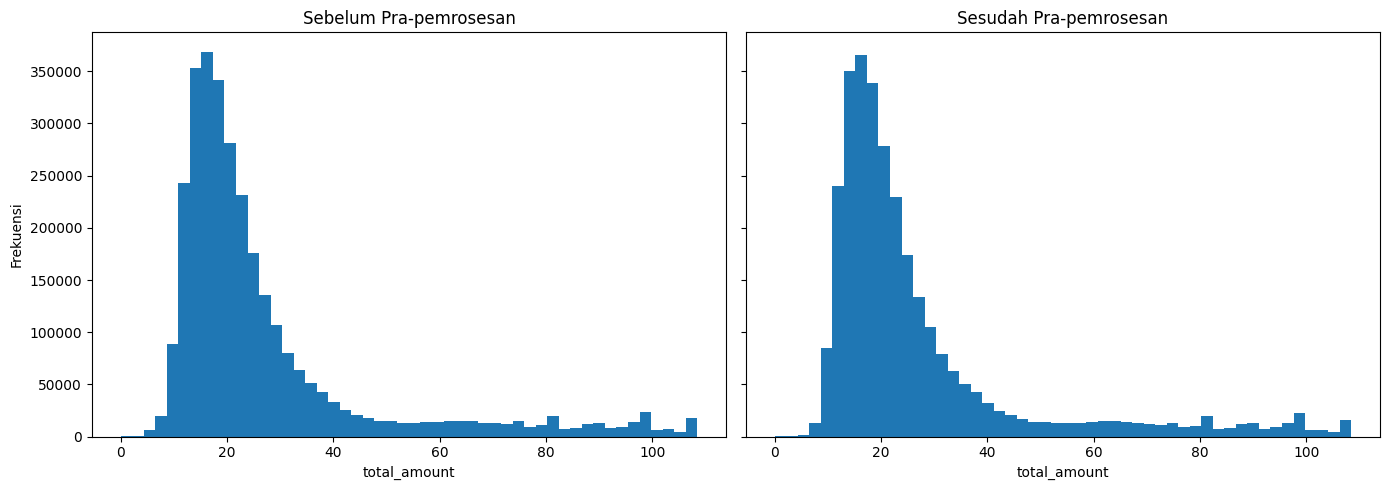

Analisis: penyaringan kualitas mengurangi transaksi yang melanggar aturan kewajaran, sehingga bagian ekstrem distribusi sesudah pra-pemrosesan perlu dibandingkan dengan distribusi awal.


In [13]:
import matplotlib.pyplot as plt
sebelum_plot=trip.total_amount.dropna(); sesudah_plot=hasil.total_amount.dropna(); xmax=max(float(pd.concat([sebelum_plot,sesudah_plot]).quantile(.995)),1.0); bins=np.linspace(0,xmax,51)
fig,ax=plt.subplots(1,2,figsize=(14,5),sharex=True,sharey=True); ax[0].hist(sebelum_plot.clip(upper=xmax),bins=bins); ax[0].set_title('Sebelum Pra-pemrosesan'); ax[0].set_xlabel('total_amount'); ax[0].set_ylabel('Frekuensi'); ax[1].hist(sesudah_plot.clip(upper=xmax),bins=bins); ax[1].set_title('Sesudah Pra-pemrosesan'); ax[1].set_xlabel('total_amount'); plt.tight_layout(); plt.show()
print('Analisis: penyaringan kualitas mengurangi transaksi yang melanggar aturan kewajaran, sehingga bagian ekstrem distribusi sesudah pra-pemrosesan perlu dibandingkan dengan distribusi awal.')

# P. Studi Kasus — Tim Penetapan Harga Dinamis
Tabel analitik satu baris per borough per jam, dengan jumlah perjalanan, median tarif per mil, median kecepatan, suhu, dan penanda hujan. Modul menyebut metrik sebagai rata-rata tetapi kode modul menggunakan `median`; kode dipertahankan mengikuti modul.

In [14]:
tabel_analitik=(bersih.assign(jam_mulai=bersih['tpep_pickup_datetime'].dt.floor('h')).groupby(['borough_naik','jam_mulai'],observed=True).agg(jumlah_perjalanan=('total_amount','size'),rata_tarif_per_mil=('tarif_per_mil','median'),rata_kecepatan=('kecepatan_mph','median'),suhu_c=('suhu_c','first'),hujan=('hujan','max')).reset_index())
tabel_analitik=tabel_analitik[tabel_analitik.jumlah_perjalanan>=30].copy(); tabel_analitik.to_parquet(os.path.join(DIR_KURASI,'tabel_analitik_pricing.parquet'),index=False)
print('Baris tabel analitik:',len(tabel_analitik)); display(tabel_analitik.groupby(['borough_naik','hujan'],observed=True)['rata_tarif_per_mil'].median().unstack()); display(tabel_analitik.head())

Baris tabel analitik: 2094


hujan,0,1
borough_naik,,
Brooklyn,6.9430,7.6550
Manhattan,10.5270,11.4000
Queens,5.4530,5.6365
Unknown,8.7255,9.8860


,borough_naik,jam_mulai,jumlah_perjalanan,rata_tarif_per_mil,rata_kecepatan,suhu_c,hujan
626,Brooklyn,2023-01-01 00:00:00,86,6.9385,14.550,10.9,1
627,Brooklyn,2023-01-01 01:00:00,220,6.9820,13.715,10.6,1
628,Brooklyn,2023-01-01 02:00:00,256,6.6215,15.445,10.6,0
629,Brooklyn,2023-01-01 03:00:00,175,6.6160,16.390,10.5,0
630,Brooklyn,2023-01-01 04:00:00,74,6.9120,14.635,9.8,0


### Jawaban studi kasus
Dugaan pricing harus dijawab dari tabel hasil: bandingkan `rata_tarif_per_mil` pada `hujan=1` dan `hujan=0` untuk setiap borough. Batasan minimal: (1) median digunakan karena distribusi dapat miring dan memiliki ekstrem; (2) cuaca diukur pada satu titik untuk seluruh kota; (3) korelasi bukan sebab-akibat dan hujan dapat berbarengan dengan jam sibuk; (4) kelompok <30 perjalanan dibuang; (5) hanya satu bulan data yang digunakan; (6) tarif per mil dapat sangat besar pada perjalanan dengan jarak sangat kecil.

In [15]:
kamus="""# Kamus Data — Tabel Analitik Pricing

| Kolom | Tipe | Satuan | Sumber | Perhitungan |
|---|---|---|---|---|
| borough_naik | object | wilayah | Taxi Zone Lookup | join PULocationID |
| jam_mulai | datetime64 | jam | TLC | floor ke jam |
| jumlah_perjalanan | int | perjalanan | TLC | jumlah baris per borough-jam |
| rata_tarif_per_mil | float | mata uang/mil | TLC | median total_amount/trip_distance |
| rata_kecepatan | float | mil/jam | TLC | median trip_distance/(durasi/60) |
| suhu_c | float | Celsius | Open-Meteo | suhu pada jam terkait |
| hujan | int | 0/1 | Open-Meteo | 1 jika hujan_mm > 0.1 |

Kelompok dengan kurang dari 30 perjalanan tidak digunakan. Missing `passenger_count` diisi median per jam lalu median global."""
with open(os.path.join(DIR_SIMPAN,'kamus_data.md'),'w',encoding='utf-8') as f: f.write(kamus)
print('kamus_data.md tersimpan')

kamus_data.md tersimpan


# Q. Latihan

### Latihan 1 — Kecepatan unduh dan cache

In [16]:
def unduh_aman_dengan_kecepatan(url,tujuan,percobaan=3,jeda_awal=2):
    if os.path.exists(tujuan) and os.path.getsize(tujuan)>0: print('cache ditemukan:',os.path.basename(tujuan)); return tujuan
    sementara=tujuan+'.part'
    for i in range(percobaan):
        try:
            t0=time.perf_counter()
            with requests.get(url,stream=True,timeout=60) as r:
                r.raise_for_status()
                with open(sementara,'wb') as f: shutil.copyfileobj(r.raw,f)
            mb=os.path.getsize(sementara)/1024**2; dt=time.perf_counter()-t0; os.replace(sementara,tujuan); print(f'kecepatan unduh: {mb/dt:.2f} MB/detik'); return tujuan
        except Exception as e: time.sleep(jeda_awal*(2**i))
    raise RuntimeError('gagal mengunduh')
print('Panggilan 1:'); unduh_aman_dengan_kecepatan(URL_TRIP,PATH_TRIP); print('Panggilan 2:'); unduh_aman_dengan_kecepatan(URL_TRIP,PATH_TRIP)

Panggilan 1:
cache ditemukan: yellow_tripdata_2023-01.parquet
Panggilan 2:
cache ditemukan: yellow_tripdata_2023-01.parquet


'/content/lapisan_mentah/yellow_tripdata_2023-01.parquet'

### Latihan 2 — Dua aturan kualitas tambahan

In [17]:
aturan_latihan2=dict(aturan); aturan_latihan2['validitas: tip_amount >= 0']=trip.tip_amount>=0; aturan_latihan2['konsistensi: tip <= total_amount']=trip.tip_amount<=trip.total_amount
laporan_latihan2=pd.DataFrame([{'aturan':n,'lulus':int(m.sum()),'gagal':int((~m).sum()),'persen_gagal':round(100*(~m).mean(),3)} for n,m in aturan_latihan2.items()]); display(laporan_latihan2[laporan_latihan2.aturan.str.contains('tip')])

,aturan,lulus,gagal,persen_gagal
8,validitas: tip_amount >= 0,3066540,225,0.007
9,konsistensi: tip <= total_amount,3041561,25204,0.822


### Latihan 3 — Join lokasi tujuan dan 10 pasangan borough tersibuk

In [18]:
z_tujuan=zona[['LocationID','Borough']].rename(columns={'LocationID':'DOLocationID','Borough':'borough_tujuan'}); latihan3=bersih.merge(z_tujuan,on='DOLocationID',how='left',validate='many_to_one'); sepuluh_pasangan=latihan3.groupby(['borough_naik','borough_tujuan'],dropna=False,observed=True).size().reset_index(name='jumlah_perjalanan').sort_values('jumlah_perjalanan',ascending=False).head(10); display(sepuluh_pasangan)

,borough_naik,borough_tujuan,jumlah_perjalanan
25,Manhattan,Manhattan,2491566
33,Queens,Manhattan,155261
26,Manhattan,Queens,82354
23,Manhattan,Brooklyn,62986
34,Queens,Queens,59146
31,Queens,Brooklyn,42187
48,Unknown,Manhattan,18432
51,Unknown,Unknown,13562
22,Manhattan,Bronx,8865
9,Brooklyn,Brooklyn,7910


### Latihan 4 — MinMaxScaler vs StandardScaler
Perbedaan paling penting untuk algoritma yang sensitif terhadap jarak, gradien, atau regularisasi. Untuk tree-based model, skala biasanya tidak menjadi penentu utama pemisahan.

In [19]:
from sklearn.preprocessing import MinMaxScaler
mm=MinMaxScaler().fit(latih[FITUR_NUM]); latih_mm=mm.transform(latih[FITUR_NUM]); display(pd.DataFrame({'fitur':FITUR_NUM,'standard_min':latih_num.min(0),'standard_max':latih_num.max(0),'minmax_min':latih_mm.min(0),'minmax_max':latih_mm.max(0)}))

,fitur,standard_min,standard_max,minmax_min,minmax_max
0,trip_distance_capped,-0.793948,4.246792,0.0,1.0
1,durasi_menit,-1.225975,13.924810,0.0,1.0
2,suhu_c,-2.288100,3.347487,0.0,1.0


### Latihan 5 — Membuktikan `validate="many_to_one"`

In [20]:
zona_backup=zona.copy(); zona_salah=pd.concat([zona,zona.iloc[[0]]],ignore_index=True)
try:
    bersih.merge(zona_salah[['LocationID','Borough','Zone']].rename(columns={'Borough':'borough_naik','Zone':'zona_naik'}),left_on='PULocationID',right_on='LocationID',how='left',validate='many_to_one')
    print('Tidak muncul error — periksa kunci contoh.')
except Exception as e: print('Error yang diharapkan:',type(e).__name__,str(e)[:400])
zona=zona_backup; print('Tabel zona dikembalikan:',len(zona),'baris')

Error yang diharapkan: MergeError Merge keys are not unique in right dataset; not a many-to-one merge
Tabel zona dikembalikan: 265 baris


### Latihan 6 — `pipeline_inkremental(bulan)`

In [21]:
def pipeline_inkremental(bulan):
    nama=pd.Timestamp(bulan).strftime('%Y-%m'); target=os.path.join(DIR_KURASI,f'inkremental_{nama}')
    if os.path.exists(target) and os.listdir(target): print('output sudah ada; dilewati:',target); return target
    df=pipeline(PATH_TRIP,PATH_ZONA,cuaca,tarif_referensi); df['bulan']=df.tpep_pickup_datetime.dt.strftime('%Y-%m'); df=df[df.bulan==nama]
    if df.empty: print('Tidak ada data untuk',nama); return None
    df.to_parquet(target,index=False); print('output dibuat:',target); return target
ink1=pipeline_inkremental('2023-01'); ink2=pipeline_inkremental('2023-01'); print('Idempoten:',ink1==ink2)

Validasi lulus: 2,986,910 baris x 17 kolom
output dibuat: /content/lapisan_terkurasi/inkremental_2023-01


NotADirectoryError: [Errno 20] Not a directory: '/content/lapisan_terkurasi/inkremental_2023-01'

In [22]:
def pipeline_incremental(bulan):
    nama = pd.Timestamp(bulan).strftime("%Y-%m")
    target = os.path.join(
        DIR_KURASI,
        f"incremental_{nama}.parquet"
    )

    if os.path.exists(target):
        print("output sudah ada, dilewati:", target)
        return target

    df = pipeline(
        PATH_TRIP,
        PATH_ZONA,
        cuaca,
        tarif_referensi
    )

    df["bulan"] = (
        df["tpep_pickup_datetime"]
        .dt.strftime("%Y-%m")
    )

    df = df[df["bulan"] == nama]

    if df.empty:
        print("Tidak ada data untuk", nama)
        return None

    df.to_parquet(target, index=False)

    print("output dibuat:", target)
    return target


ink1 = pipeline_incremental("2023-01")
ink2 = pipeline_incremental("2023-01")

print("Idempoten:", ink1 == ink2)

Validasi lulus: 2,986,910 baris x 17 kolom
output dibuat: /content/lapisan_terkurasi/incremental_2023-01.parquet
output sudah ada, dilewati: /content/lapisan_terkurasi/incremental_2023-01.parquet
Idempoten: True


# R. Tugas Praktikum
**Batas waktu modul:** 7 hari setelah praktikum melalui LMS. Notebook menyediakan kode/kerangka untuk seluruh tugas.

### Tugas 1 — Pipeline dua bulan
Jalankan untuk dua bulan berbeda dan tulis pada direktori berpartisi yang sama. Periksa duplikasi antarbulan.

In [25]:
def akuisisi_bulan(bulan):
    bulan = pd.Timestamp(bulan)
    ym = bulan.strftime("%Y-%m")

    url = (
        "https://d37ci6vzurychx.cloudfront.net/trip-data/"
        f"yellow_tripdata_{ym}.parquet"
    )

    path = os.path.join(
        DIR_MENTAH,
        f"yellow_tripdata_{ym}.parquet"
    )

    return unduh_aman(url, path)


def ambil_cuaca_bulan(bulan):
    bulan = pd.Timestamp(bulan)

    mulai = bulan.strftime("%Y-%m-%d")
    selesai = (
        bulan + pd.offsets.MonthEnd(0)
    ).strftime("%Y-%m-%d")

    return ambil_cuaca(
        mulai,
        selesai
    )

In [26]:
def ambil_cuaca_bulan(bulan):
    awal = pd.Timestamp(bulan).replace(day=1)
    akhir = (awal + pd.offsets.MonthEnd(1)).normalize()
    return ambil_cuaca(awal.strftime('%Y-%m-%d'), akhir.strftime('%Y-%m-%d'))

def pipeline_bulan(bulan):
    ym = pd.Timestamp(bulan).strftime("%Y-%m")

    path = akuisisi_bulan(bulan)
    cuaca_bulan = ambil_cuaca_bulan(bulan)

    cuaca_bulan["time"] = pd.to_datetime(
        cuaca_bulan["time"]
    )

    cuaca_bulan = cuaca_bulan.rename(
        columns={
            "time": "jam_mulai",
            "temperature_2m": "suhu_c",
            "precipitation": "hujan_mm"
        }
    )

    hasil = pipeline(
        path,
        PATH_ZONA,
        cuaca_bulan,
        tarif_referensi
    )

    hasil["bulan"] = ym

    return hasil

    df = pd.read_parquet(path, columns=KOLOM)
    df['durasi_menit'] = ((df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60)
    df['jam'] = df['tpep_pickup_datetime'].dt.hour
    df['passenger_count'] = df['passenger_count'].fillna(df.groupby('jam')['passenger_count'].transform('median'))
    df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())
    df = df.drop_duplicates(subset=KUNCI)
    df = df[df['trip_distance'].between(0.01,100) & df['durasi_menit'].between(1,180) & (df['total_amount'] > 0)].copy()
    df = df.merge(zona[['LocationID','Borough']].rename(columns={'Borough':'borough_naik'}), left_on='PULocationID', right_on='LocationID', how='left', validate='many_to_one').drop(columns='LocationID')
    df = df.merge(tarif_referensi[['payment_type','nama_pembayaran']], on='payment_type', how='left', validate='many_to_one')
    df['jam_mulai'] = df['tpep_pickup_datetime'].dt.floor('h')
    df = df.merge(cuaca_bulan, on='jam_mulai', how='left', validate='many_to_one')
    df['bulan'] = ym
    return df

In [27]:
jan_2023 = pipeline_bulan("2023-01-01")
jul_2023 = pipeline_bulan("2023-07-01")

dua_bulan = pd.concat(
    [jan_2023, jul_2023],
    ignore_index=True
)

print("Januari:", len(jan_2023))
print("Juli:", len(jul_2023))
print("Gabungan:", len(dua_bulan))

print(
    dua_bulan["bulan"].value_counts()
)

cache ditemukan: yellow_tripdata_2023-01.parquet
Validasi lulus: 2,986,910 baris x 17 kolom
Validasi lulus: 2,817,657 baris x 17 kolom
Januari: 2986910
Juli: 2817657
Gabungan: 5804567
bulan
2023-01    2986910
2023-07    2817657
Name: count, dtype: int64


### Tugas 2 — Laporan kualitas komparatif
Bandingkan dua laporan kualitas dengan join pada kolom `aturan` dan hitung perubahan persentase poin.

In [28]:
def bandingkan_laporan_kualitas(a,b):
    x=a[['aturan','persen_gagal']].rename(columns={'persen_gagal':'persen_gagal_a'}); y=b[['aturan','persen_gagal']].rename(columns={'persen_gagal':'persen_gagal_b'}); z=x.merge(y,on='aturan',how='outer'); z['perubahan_persen_poin']=z.persen_gagal_b-z.persen_gagal_a; return z.sort_values('perubahan_persen_poin',key=lambda s:s.abs(),ascending=False)
display(laporan)

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


### Tugas 3 — Sumber keempat
Contoh legal/public API: Nager.Date Public Holidays. Jika endpoint tidak tersedia, kegagalan ditangani tanpa merusak pipeline utama.

In [29]:
URL_LIBUR='https://date.nager.at/api/v3/PublicHolidays/2023/US'
try:
    r=requests.get(URL_LIBUR,timeout=30); r.raise_for_status(); libur=pd.DataFrame(r.json()); print('Baris sumber keempat:',len(libur)); display(libur.head())
except Exception as e: print('Sumber keempat tidak tersedia pada runtime ini:',repr(e)); libur=pd.DataFrame()

Baris sumber keempat: 17


,date,localName,name,countryCode,fixed,global,counties,launchYear,types
0,2023-01-02,New Year's Day,New Year's Day,US,False,True,None,None,"[Public, Bank]"
1,2023-01-16,"Martin Luther King, Jr. Day","Martin Luther King, Jr. Day",US,False,True,None,None,"[Public, Bank]"
2,2023-02-12,Lincoln's Birthday,Lincoln's Birthday,US,False,False,"[US-CA, US-CT, US-IL, US-IN, US-KY, US-MI, US-...",None,[Observance]
3,2023-02-20,Washington's Birthday,Presidents Day,US,False,True,None,None,"[Public, Bank]"
4,2023-04-07,Good Friday,Good Friday,US,False,False,"[US-CT, US-DE, US-HI, US-IN, US-KY, US-LA, US-...",None,[Public]


### Tugas 4 — Kamus data
`kamus_data.md` dibuat pada bagian Studi Kasus.

### Tugas 5 — Dokumen lineage
`lineage.csv` dibuat pada K-10. Diagram satu halaman: **NYC TLC + Taxi Zone Lookup + Open-Meteo + SQLite → lapisan mentah → profiling → missing value → duplicate → outlier → join → feature engineering → validasi → trips_bersih → tabel analitik**. Tandai titik pembuangan baris.

### Tugas 6 — Reproducibility
Lakukan **Runtime → Restart session → Run all**. Cache input, validasi schema, dan output deterministik digunakan untuk mendukung pengulangan. K-11 tidak wajib dan dapat dilewati bila runtime tidak kompatibel.

# S. Pertanyaan Evaluasi dan Jawaban

### 1. Jelaskan perbedaan ETL dan ELT, dan mengapa ELT lebih lazim pada sistem Big Data modern.
ETL mentransformasi data sebelum dimuat; ELT memuat data mentah lebih dahulu lalu mentransformasikannya. ELT lazim karena penyimpanan murah dan data mentah dapat diproses ulang ketika aturan/definisi berubah.

### 2. Sebutkan tiga risiko akuisisi data lewat API dan cara menanganinya. Kode HTTP mana yang layak dicoba ulang?
Risikonya antara lain rate limit, gangguan server sementara, dan perubahan struktur respons. Gunakan timeout, validasi JSON, serta retry exponential backoff untuk 429 dan gangguan 5xx seperti 500, 502, 503. Kesalahan klien permanen umumnya tidak perlu di-retry otomatis.

### 3. Apa perbedaan MCAR, MAR, dan MNAR?
MCAR: missing tidak bergantung pada variabel teramati maupun tidak teramati. MAR: missing dapat dijelaskan oleh variabel yang teramati. MNAR: missing berkaitan dengan nilai yang hilang atau faktor tak teramati. Contoh MNAR: tip kosong karena pelanggan memang tidak memberi tip; imputasi median dapat mengubah makna.

### 4. Mengapa Z-score kurang sesuai untuk distribusi sangat miring ke kanan?
Mean dan simpangan baku sensitif terhadap nilai ekstrem. Pada distribusi miring, Z-score dapat memberi batas yang kurang representatif. IQR lebih robust terhadap pencilan.

### 5. Apa yang terjadi bila tabel referensi pada join many-to-one memiliki kunci ganda?
Satu baris data utama dapat cocok dengan beberapa baris referensi sehingga jumlah baris hasil join membesar. Cegah dengan memastikan kunci referensi unik dan menggunakan validate="many_to_one".

### 6. Jelaskan data leakage dalam scaling fitur.
Leakage terjadi ketika parameter scaler dipelajari dari data uji. Urutan benar: split train/test, fit scaler hanya pada train, transform train dan test.

### 7. Apa arti pipeline idempoten?
Menjalankan pipeline berulang dengan input sama tidak menimbulkan perubahan yang tidak semestinya. Contoh teknik: caching dan output deterministik dengan pengecekan keberadaan hasil.

### 8. Mengapa partisi pada kolom kardinalitas tinggi merugikan?
Menghasilkan terlalu banyak partisi/file kecil, metadata dan overhead meningkat, serta pembacaan menjadi lebih mahal. Gejalanya banyak direktori/file kecil.

### 9. Apa yang harus diperiksa sebelum scraping data ulasan e-commerce?
Periksa ketentuan/izin penggunaan, robots.txt atau kebijakan akses yang relevan, rate limit, dan privasi data. Tolak jika pengambilan melanggar ketentuan akses/izin atau mengambil data pribadi secara tidak semestinya.

# T. Kesimpulan
Praktikum ini menunjukkan bahwa akuisisi adalah rekayasa: caching, penulisan atomik, retry, validasi respons, dan lineage diperlukan agar data dapat dipertanggungjawabkan. Pra-pemrosesan adalah rangkaian keputusan yang mengubah data sehingga setiap ambang, imputasi, dan pembuangan harus dijelaskan dan diukur. Pipeline yang baik bersifat idempoten dan tervalidasi.

# Checklist Pengumpulan
- Notebook `.ipynb` dengan output.
- `trips_bersih/` Parquet berpartisi.
- `laporan_kualitas.csv`.
- `lineage.csv`.
- `kamus_data.md`.
- `pengukuran_kinerja.csv`.
- `trips_bersih.zip`.
- Grafik sebelum/sesudah.
- Studi kasus, analisis hasil, latihan, tugas, dan evaluasi.

**Penting:** angka yang bergantung pada runtime harus berasal dari output aktual setelah notebook dijalankan; jangan menyalin angka contoh dari modul.